# Robustez do modelo YOLO a detecção de objetos

* Estudar a qualidade da detecção de acordo com o tamanho de objetos
* Escolher 4 classes do COCO e obter ao menos 2 objetos distintos de cada classe
* Para cada objeto, tirar fotos com ao menos 5 distâncias distintas, de forma que o objeto possua diferentes tamanhos na imagem final (grande, muito pequeno, etc) definido de forma aproximada como a porcentagem da área do objeto em relação à imagem (50%, 10%, 5%, etc).
* Quantificar a robustez do modelo nano (YOLO26n) e médio (YOLO26m) e large (YOLO26l) em relação ao tamanho do objeto. Lembrando que o modelo redimensiona a imagem para 640 pixels. Esse valor deve ser mantido no modelo.
* Analisar: A confiança (probabilidade) do modelo em cada caso, e se a qualidade depende da categoria do objeto
* Identificar os limites do modelo. Para que tamanho o modelo começa a falhar?
* Repetir a análise mas utilizando como entrada imagens com o dobro de tamanho (2*640)

Exemplo de visualização de resultados (não precisa ser necessariamente um gráfico de barras e essas porcentagens de tamanho):

![exemplo](exemplo_resultado.png)

In [1]:
from ultralytics import YOLO
import torch
from torch import nn
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from PIL import Image
import os
from pathlib import Path


In [2]:
# Define the folder path
folder_path = Path("Dataset/T2 - VC")

# Define the extensions you want to target
valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Loop through files and open images
loaded_images = []
for file_path in folder_path.iterdir():
    if file_path.suffix.lower() in valid_extensions:
        img = Image.open(file_path)
        loaded_images.append(img)
        print(f"Loaded: {file_path.name}")

Loaded: BikeA_0.jpg
Loaded: BikeA_0_0.jpg
Loaded: BikeA_1.jpg
Loaded: BikeA_10.jpg
Loaded: BikeA_25.jpg
Loaded: BikeA_5.jpg
Loaded: BikeA_50.jpg
Loaded: BikeF_0.jpg
Loaded: BikeF_1.jpg
Loaded: BikeF_10.jpg
Loaded: BikeF_25(1).jpg
Loaded: BikeF_25.jpg
Loaded: BikeF_5.jpg
Loaded: BikeF_50.jpg
Loaded: CarroB_1.jpg
Loaded: CarroB_10.jpg
Loaded: CarroB_1_2.jpg
Loaded: CarroB_25.jpg
Loaded: CarroB_5.jpg
Loaded: CarroB_50.jpg
Loaded: CarroV_1.jpg
Loaded: CarroV_10.jpg
Loaded: CarroV_1_2.jpg
Loaded: CarroV_25.jpg
Loaded: CarroV_5.jpg
Loaded: CarroV_50.jpg
Loaded: CopoS_0.jpg
Loaded: CopoS_1.jpg
Loaded: CopoS_10.jpg
Loaded: CopoS_25.jpg
Loaded: CopoS_5.jpg
Loaded: CopoS_50.jpg
Loaded: CopoVidro_1.jpg
Loaded: CopoVidro_10.jpg
Loaded: CopoVidro_25.jpg
Loaded: CopoVidro_5.jpg
Loaded: CopoVidro_50.jpg
Loaded: NotebookE_0.jpg
Loaded: NotebookE_1.jpg
Loaded: NotebookE_10.jpg
Loaded: NotebookE_25.jpg
Loaded: NotebookE_5.jpg
Loaded: NotebookE_50.jpg
Loaded: NotebookP_1.jpg
Loaded: NotebookP_10.jpg
Load

In [8]:
print(loaded_images)

[<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=2992x2992 at 0x1424B665160>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=2992x2992 at 0x1424B5CE850>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=2992x2992 at 0x1424B7C4410>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=2992x2992 at 0x1424B7C47D0>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=2992x2992 at 0x1424B7C4910>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=2992x2992 at 0x1424B7C4A50>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=2992x2992 at 0x1424B7C4B90>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=2992x2992 at 0x1424B7C4CD0>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=2992x2992 at 0x1424B7C4E10>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=2992x2992 at 0x1424B7C4F50>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=2992x2992 at 0x1424B7C5090>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=2992x2992 at 0x1424B

In [6]:
import re
from pathlib import Path
from PIL import Image, ImageOps
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt

root_path = Path("Dataset/T2 - VC")
valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Mapeia o nome usado no arquivo -> nome da classe no COCO (precisa bater exatamente)
CLASS_MAP = {
    "Bike": "bicycle",
    "Carro": "car",
    "Copo": "cup",
    "Notebook": "laptop",
}

def parse_filename(file_path: Path):
    stem = file_path.stem                      # "CopoVidro_50"
    name_part = stem.split("_")[0]              # "CopoVidro"
    words = re.findall(r"[A-Z][a-z]*", name_part)
    if not words:
        return None
    class_name = words[0]
    instance = "".join(words[1:]) or "0"
    return class_name, instance

records = []
for folder in sorted(root_path.iterdir()):
    if not folder.is_dir():
        continue
    m = re.match(r"(\d+)Percent", folder.name)
    if not m:
        continue
    percent = int(m.group(1))

    for file_path in sorted(folder.iterdir()):
        if file_path.suffix.lower() not in valid_extensions:
            continue
        parsed = parse_filename(file_path)
        if parsed is None:
            continue
        class_name, instance = parsed
        if class_name not in CLASS_MAP:
            print(f"Aviso: '{class_name}' não mapeado, pulando {file_path.name}")
            continue

        img = ImageOps.exif_transpose(Image.open(file_path))
        records.append({
            "img": img, "class_name": class_name,
            "coco_class": CLASS_MAP[class_name],
            "instance": instance, "percent": percent,
        })

print(f"Total de imagens carregadas: {len(records)}")

Total de imagens carregadas: 49


In [7]:
model_names = ["yolo26n.pt", "yolo26m.pt", "yolo26l.pt"]
image_sizes = [640, 1280]

def get_best_confidence(results, target_class_name):
    names = results[0].names
    best_conf = 0.0
    for box in results[0].boxes:
        if names[int(box.cls[0])] == target_class_name:
            best_conf = max(best_conf, float(box.conf[0]))
    return best_conf

rows = []
for model_name in model_names:
    print(f"\n=== Modelo: {model_name} ===")
    yolo_model = YOLO(model_name)
    for rec in records:
        for imgsz in image_sizes:
            results = yolo_model.predict(
                source=rec["img"], imgsz=imgsz, conf=0.001, iou=0.7, verbose=False
            )
            conf = get_best_confidence(results, rec["coco_class"])
            rows.append({
                "model": model_name, "imgsz": imgsz,
                "class": rec["class_name"], "instance": rec["instance"],
                "percent": rec["percent"], "confidence": conf,
            })

df = pd.DataFrame(rows)
df.to_csv("resultados_deteccao.csv", index=False)


=== Modelo: yolo26n.pt ===

=== Modelo: yolo26m.pt ===

=== Modelo: yolo26l.pt ===


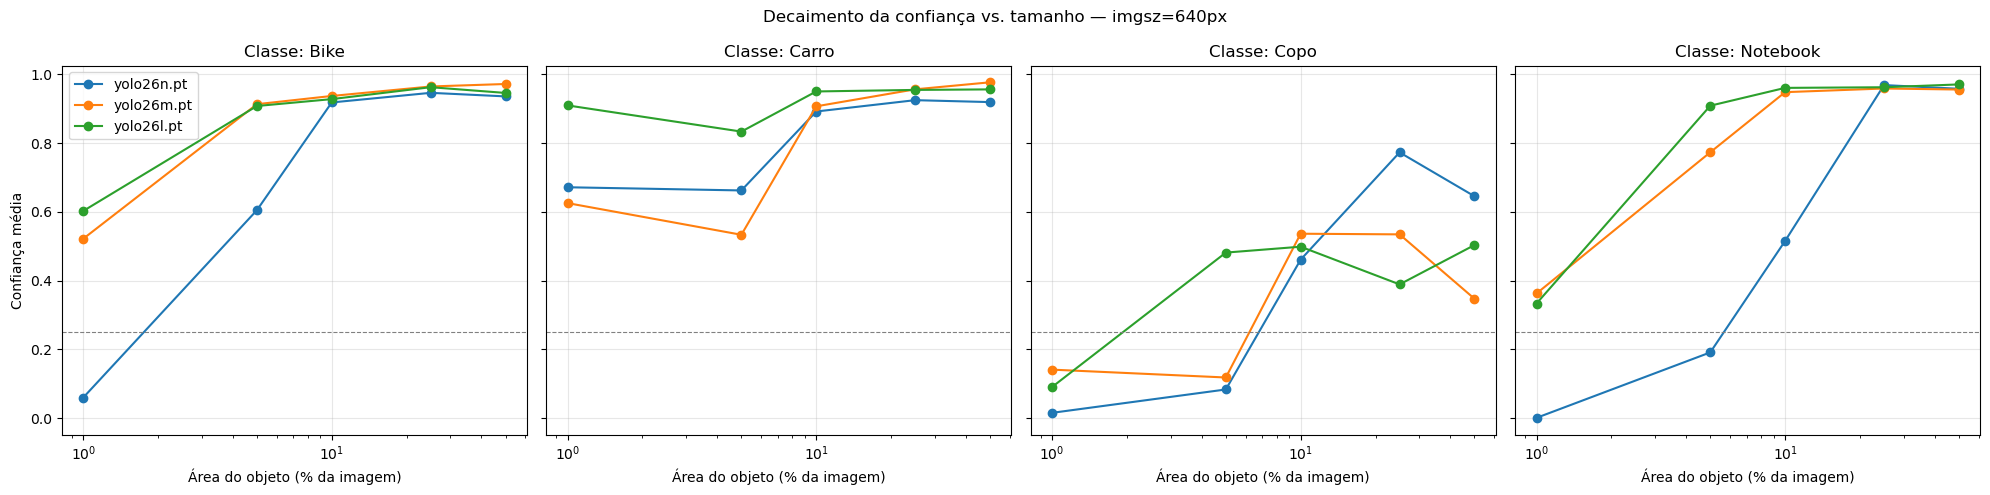

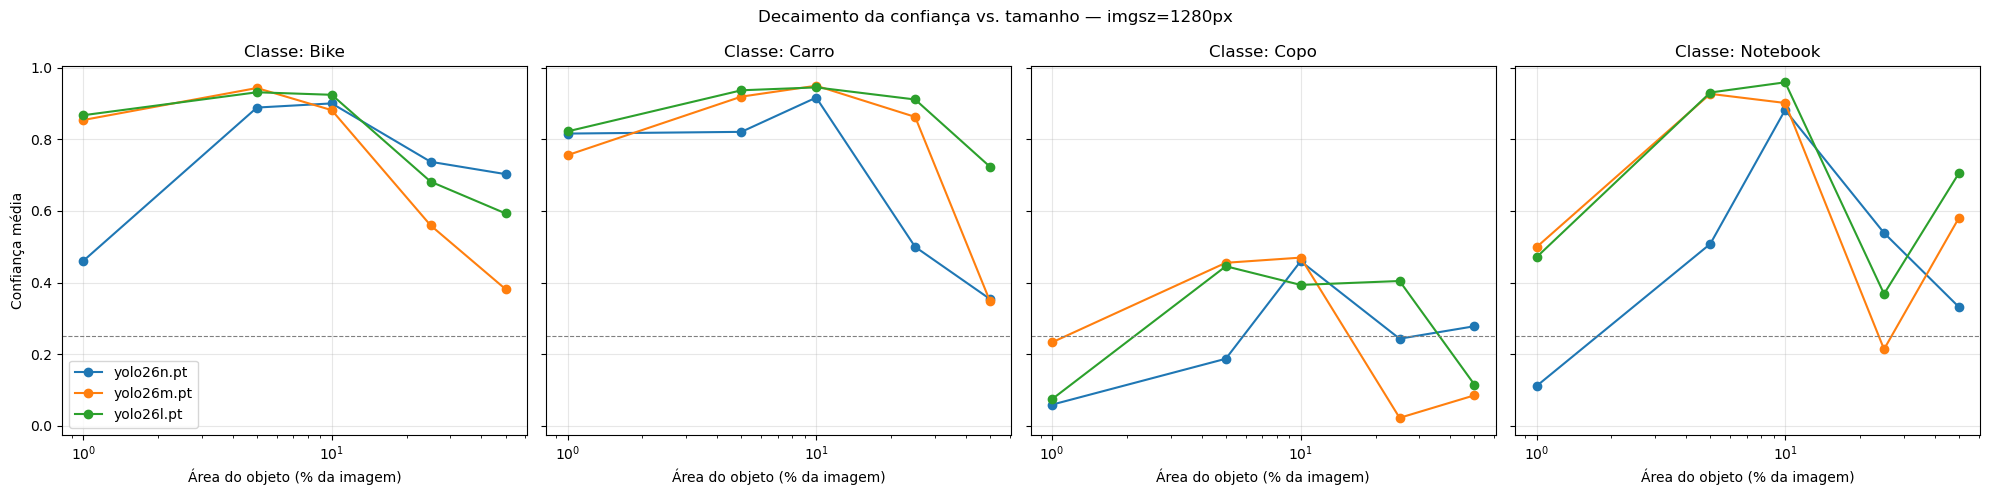

In [16]:
def plot_confidence_decay(df, imgsz_filter):
    sub = df[df["imgsz"] == imgsz_filter]
    classes = sub["class"].unique()
    fig, axes = plt.subplots(1, len(classes), figsize=(5*len(classes), 5), sharey=True)
    if len(classes) == 1:
        axes = [axes]

    for ax, cls in zip(axes, classes):
        cls_data = sub[sub["class"] == cls]
        for model_name in model_names:
            agg = (cls_data[cls_data["model"] == model_name]
                   .groupby("percent")["confidence"].mean().sort_index())
            ax.plot(agg.index, agg.values, marker="o", label=model_name)
        ax.set_title(f"Classe: {cls}")
        ax.set_xlabel("Área do objeto (% da imagem)")
        ax.set_xscale("log")
        ax.axhline(0.25, color="gray", linestyle="--", linewidth=0.8)
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Confiança média")
    axes[0].legend()
    fig.suptitle(f"Decaimento da confiança vs. tamanho — imgsz={imgsz_filter}px")
    plt.tight_layout()
    plt.savefig(f"decaimento_{imgsz_filter}px.png", dpi=150)
    plt.show()

for imgsz in image_sizes:
    plot_confidence_decay(df, imgsz)

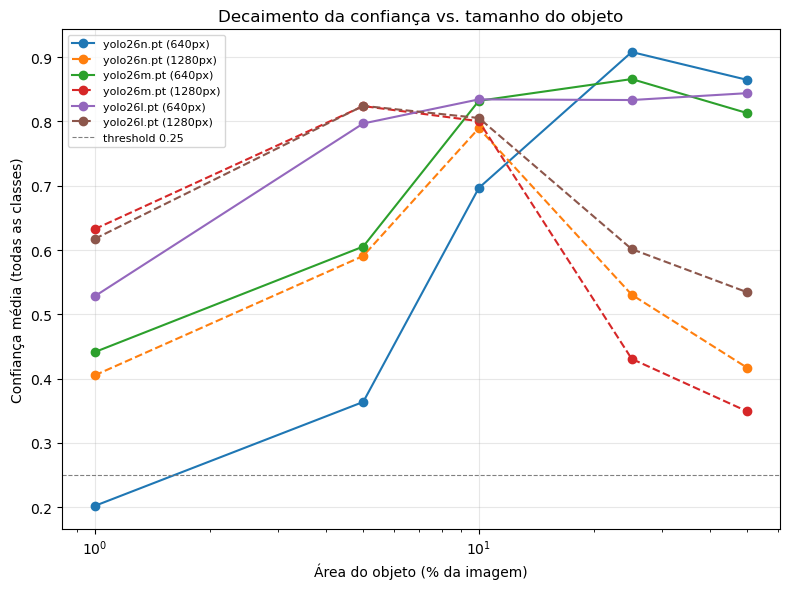

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
for model_name in model_names:
    for imgsz in image_sizes:
        sub = df[(df["model"] == model_name) & (df["imgsz"] == imgsz)]
        agg = sub.groupby("percent")["confidence"].mean().sort_index()
        ax.plot(agg.index, agg.values, marker="o",
                label=f"{model_name} ({imgsz}px)",
                linestyle="-" if imgsz == 640 else "--")

ax.set_xlabel("Área do objeto (% da imagem)")
ax.set_ylabel("Confiança média (todas as classes)")
ax.set_xscale("log")
ax.axhline(0.25, color="gray", linestyle="--", linewidth=0.8, label="threshold 0.25")
ax.set_title("Decaimento da confiança vs. tamanho do objeto")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("decaimento_geral.png", dpi=150)
plt.show()

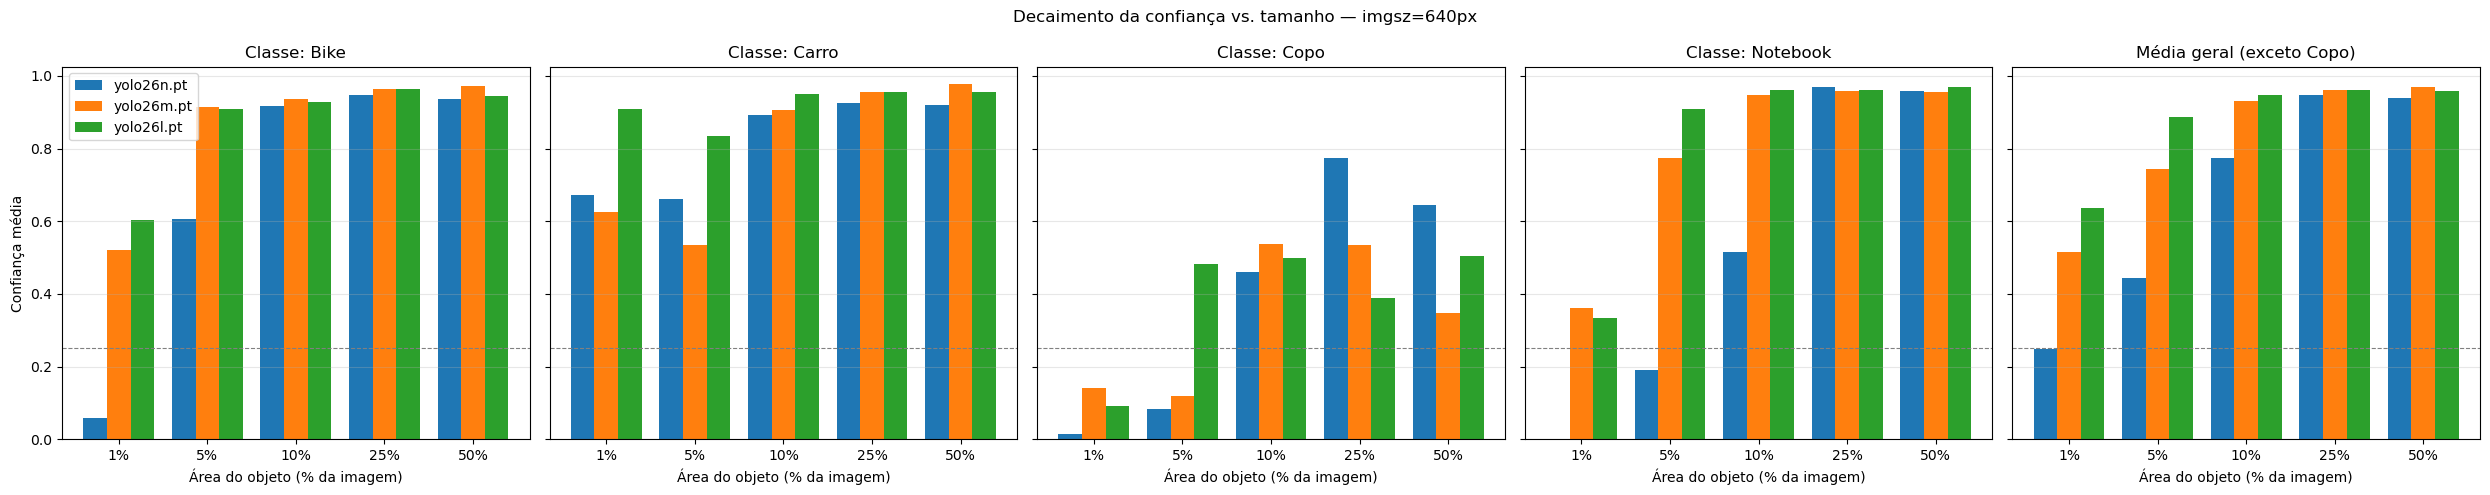

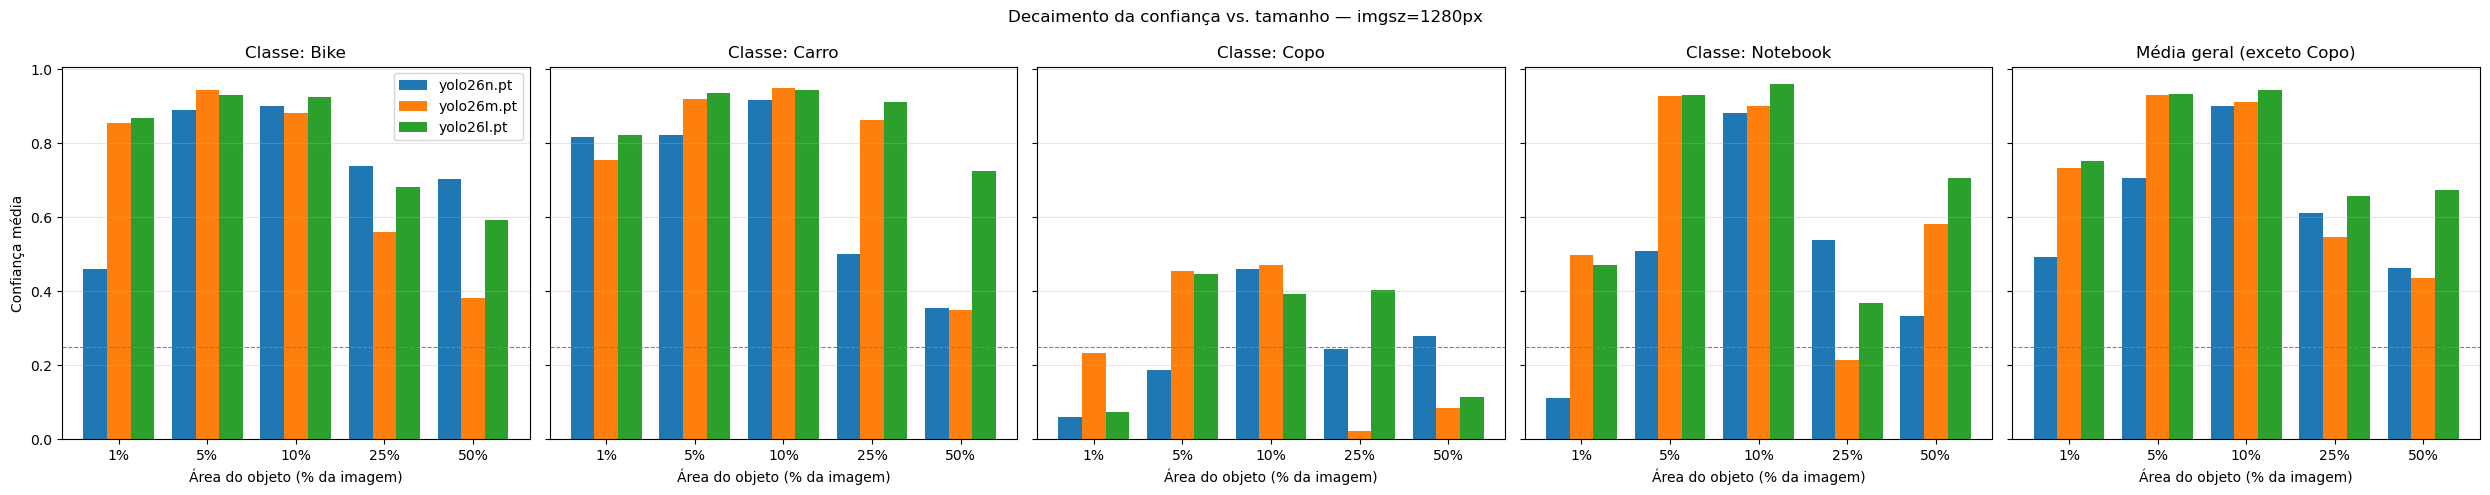

In [19]:
import numpy as np

def plot_confidence_decay(df, imgsz_filter):
    sub = df[df["imgsz"] == imgsz_filter]
    classes = sub["class"].unique()

    # +1 painel pro agregado geral (excluindo Copo)
    n_panels = len(classes) + 1
    fig, axes = plt.subplots(1, n_panels, figsize=(5*n_panels, 5), sharey=True)
    if n_panels == 1:
        axes = [axes]

    n_models = len(model_names)
    bar_width = 0.8 / n_models

    def plot_group(ax, group_data, title):
        percents = sorted(group_data["percent"].unique())
        x = np.arange(len(percents))

        for i, model_name in enumerate(model_names):
            agg = (group_data[group_data["model"] == model_name]
                   .groupby("percent")["confidence"].mean()
                   .reindex(percents, fill_value=0))
            offset = (i - (n_models - 1) / 2) * bar_width
            ax.bar(x + offset, agg.values, width=bar_width, label=model_name)

        ax.set_title(title)
        ax.set_xlabel("Área do objeto (% da imagem)")
        ax.set_xticks(x)
        ax.set_xticklabels([f"{p}%" for p in percents])
        ax.axhline(0.25, color="gray", linestyle="--", linewidth=0.8)
        ax.grid(True, alpha=0.3, axis="y")

    # painéis por classe (na ordem original)
    for ax, cls in zip(axes[:len(classes)], classes):
        cls_data = sub[sub["class"] == cls]
        plot_group(ax, cls_data, f"Classe: {cls}")

    # painel agregado: todas as classes, exceto Copo
    geral_data = sub[sub["class"] != "Copo"]
    plot_group(axes[-1], geral_data, "Média geral (exceto Copo)")

    axes[0].set_ylabel("Confiança média")
    axes[0].legend()
    fig.suptitle(f"Decaimento da confiança vs. tamanho — imgsz={imgsz_filter}px")
    plt.tight_layout()
    plt.savefig(f"decaimento_{imgsz_filter}px.png", dpi=150)
    plt.show()

for imgsz in image_sizes:
    plot_confidence_decay(df, imgsz)